# Imports and utility functions

In [1]:
import numpy as np
import glob, gc, os
import pandas as pd
import vima
np.random.seed(0)

# Set up inputs to preprocessing

In [2]:
# parameters
resolution = 10 # desired size of each pixel in microns
nmetamarkers = 10
repname = f'pca_k={nmetamarkers}_harmony'

# data location
rootdir = f'../../ALZ/alz-data'
outdir = f'{rootdir}/{resolution}u'

# Rasterize original files

In [ ]:
# define which files we will preprocess and where they'll go
files = glob.glob(f'{rootdir}/raw/middle-temporal-gyrus/*/*/cellpose-detected_transcripts.csv')
countsdir = f'{outdir}/counts'
os.makedirs(countsdir, exist_ok=True)

import time
for file in files:
    print(f'Processing {file}')
    donor = file.split('/')[-3]
    sid = file.split('/')[-2]

    vima.pp.transcriptlist_to_pixelmatrix(file, countsdir, donor, sid, 'global_x', 'global_y', 'gene', resolution)

# Preprocess

H21.33.011_1217500814: 124804 (21%) pixels non-empty| H21.33.019_1238559004: 71618 (10%) pixels non-empty| H20.33.004_1185930850: 93427 (14%) pixels non-empty| H21.33.028_1195927756: 44817 (9%) pixels non-empty| H20.33.040_1195928136: 135691 (24%) pixels non-empty| H21.33.011_1217500810: 128120 (21%) pixels non-empty| H21.33.001_1192523789: 221775 (27%) pixels non-empty| H20.33.004_1185930845: 131713 (13%) pixels non-empty| H20.33.002_1217501029: 177828 (19%) pixels non-empty| H21.33.040_1296199308: 81803 (8%) pixels non-empty| H21.33.006_1175046730: 75449 (12%) pixels non-empty| H21.33.006_1175046724: 64172 (12%) pixels non-empty| H21.33.013_1116997297: 51967 (12%) pixels non-empty| H21.33.005_1217500871: 48535 (9%) pixels non-empty| H20.33.035_1194111812: 241878 (35%) pixels non-empty| H20.33.015_1296199271: 130023 (16%) pixels non-empty| H21.33.014_1217501462: 226024 (25%) pixels non-empty| H21.33.016_1217499825: 138687 (27%) pixels non-empty| H21.33.021_1170797669: 23568 (5%) pixel

100%|███████████████████████████████████████████████████████████████| 75/75 [01:00<00:00,  1.24it/s]


computing sumstats
normalizing and writing


100%|███████████████████████████████████████████████████████████████| 75/75 [03:05<00:00,  2.47s/it]


creating metapixels prior to PCA


75it [01:34,  1.26s/it]


merging and standardizing metapixels


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


(21294616, 180)
performing PCA


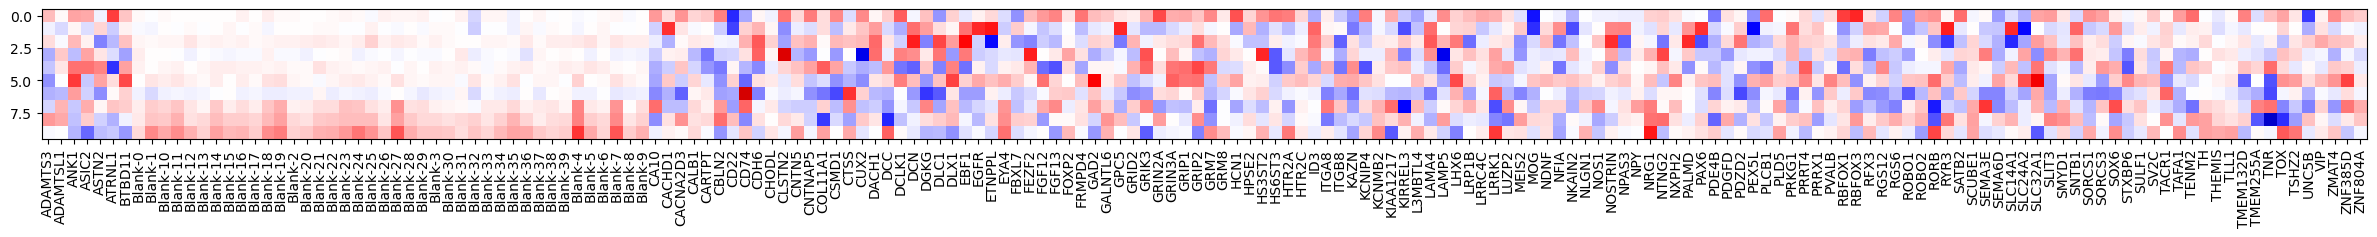

reading in pixels


100%|███████████████████████████████████████████████████████████████| 75/75 [01:11<00:00,  1.04it/s]


applying dimensionality reduction
visualizing


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


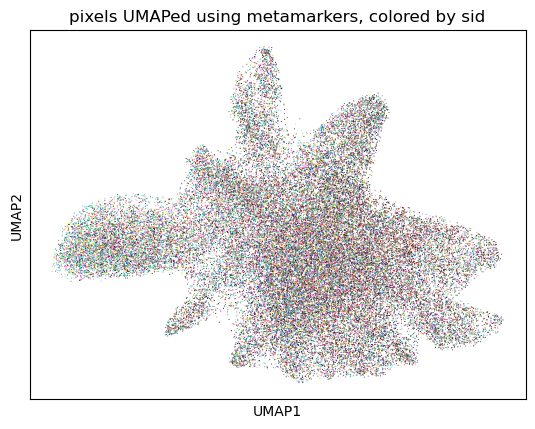

=== running harmony ===


Loading required package: Rcpp
code for methods in class “Rcpp_harmony” was not checked for suspicious field assignments (recommended package ‘codetools’ not available?)
code for methods in class “Rcpp_harmony” was not checked for suspicious field assignments (recommended package ‘codetools’ not available?)

Attaching package: ‘arrow’

The following object is masked from ‘package:utils’:

    timestamp

Transposing data matrix


harmonizing
metadata names: sid 


Initializing state using k-means centroids initialization
Harmony 1/10
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Harmony 2/10
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Harmony 3/10
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
*

writing  /var/folders/w_/x2_v44_93nq_b3svp199t1rw0000gn/T/tmpeouw9n2c_harmony.feather 
=== finished running harmony ===


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


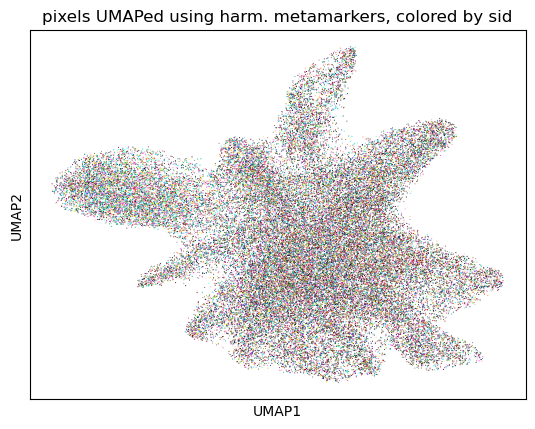

100%|███████████████████████████████████████████████████████████████| 75/75 [00:49<00:00,  1.51it/s]


In [3]:
# pre-harmony processing
allpixels_pca = vima.pp.preprocess(outdir, repname, vima.pp.foreground_mask_st, vima.pp.get_sumstats_st, vima.pp.normalize_st, nmetamarkers=nmetamarkers)

harmpixels = vima.pp.harmonize(allpixels_pca, '/Users/yakir/miniconda3/envs/Renv/bin/Rscript')
vima.pp.write_harmonized(outdir, repname, harmpixels)

all PCs of one sample


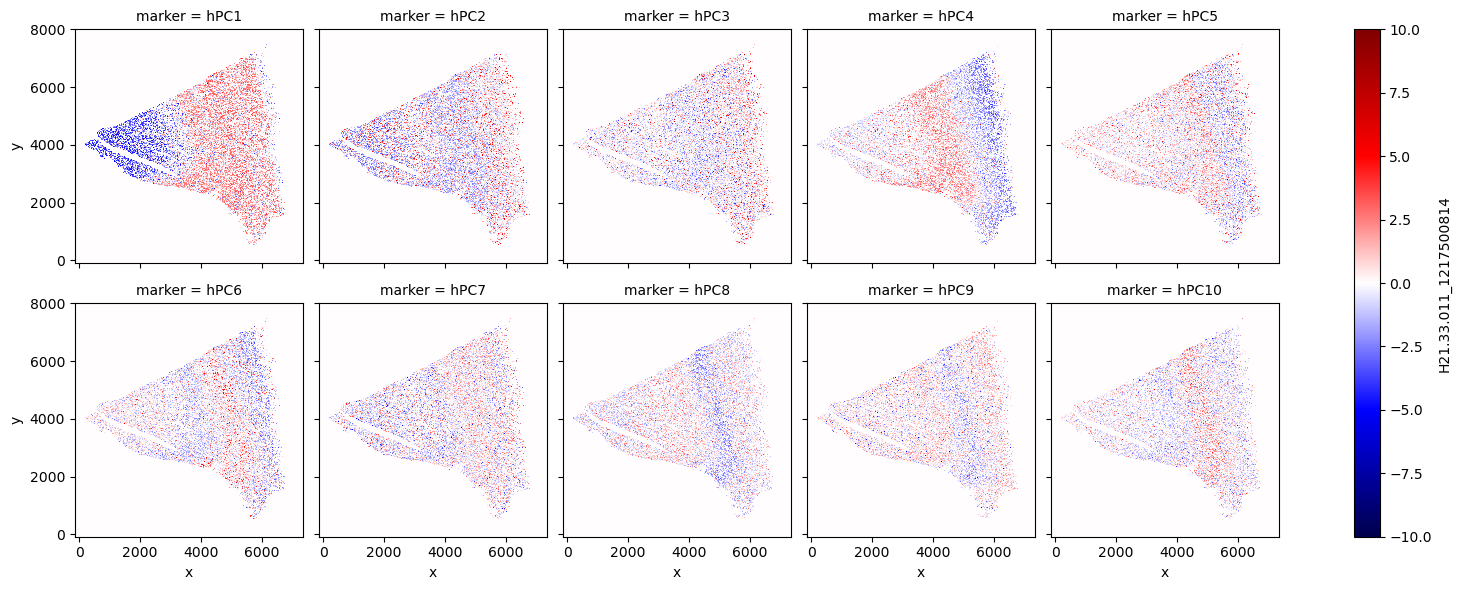

histogram of each pc
0123456789

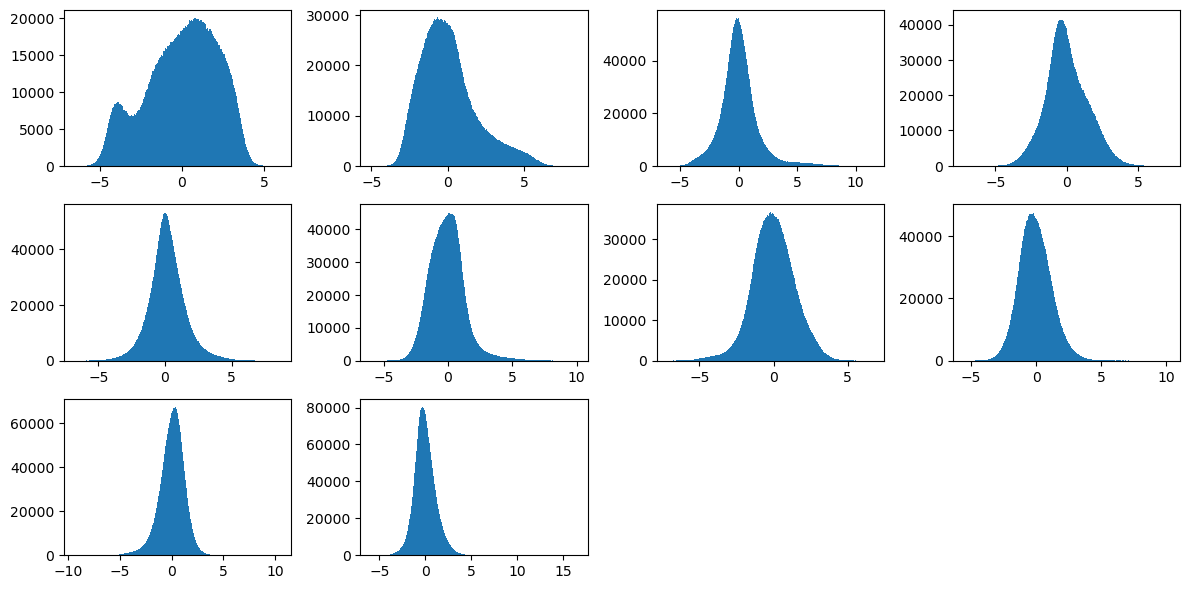

PC1 of several samples


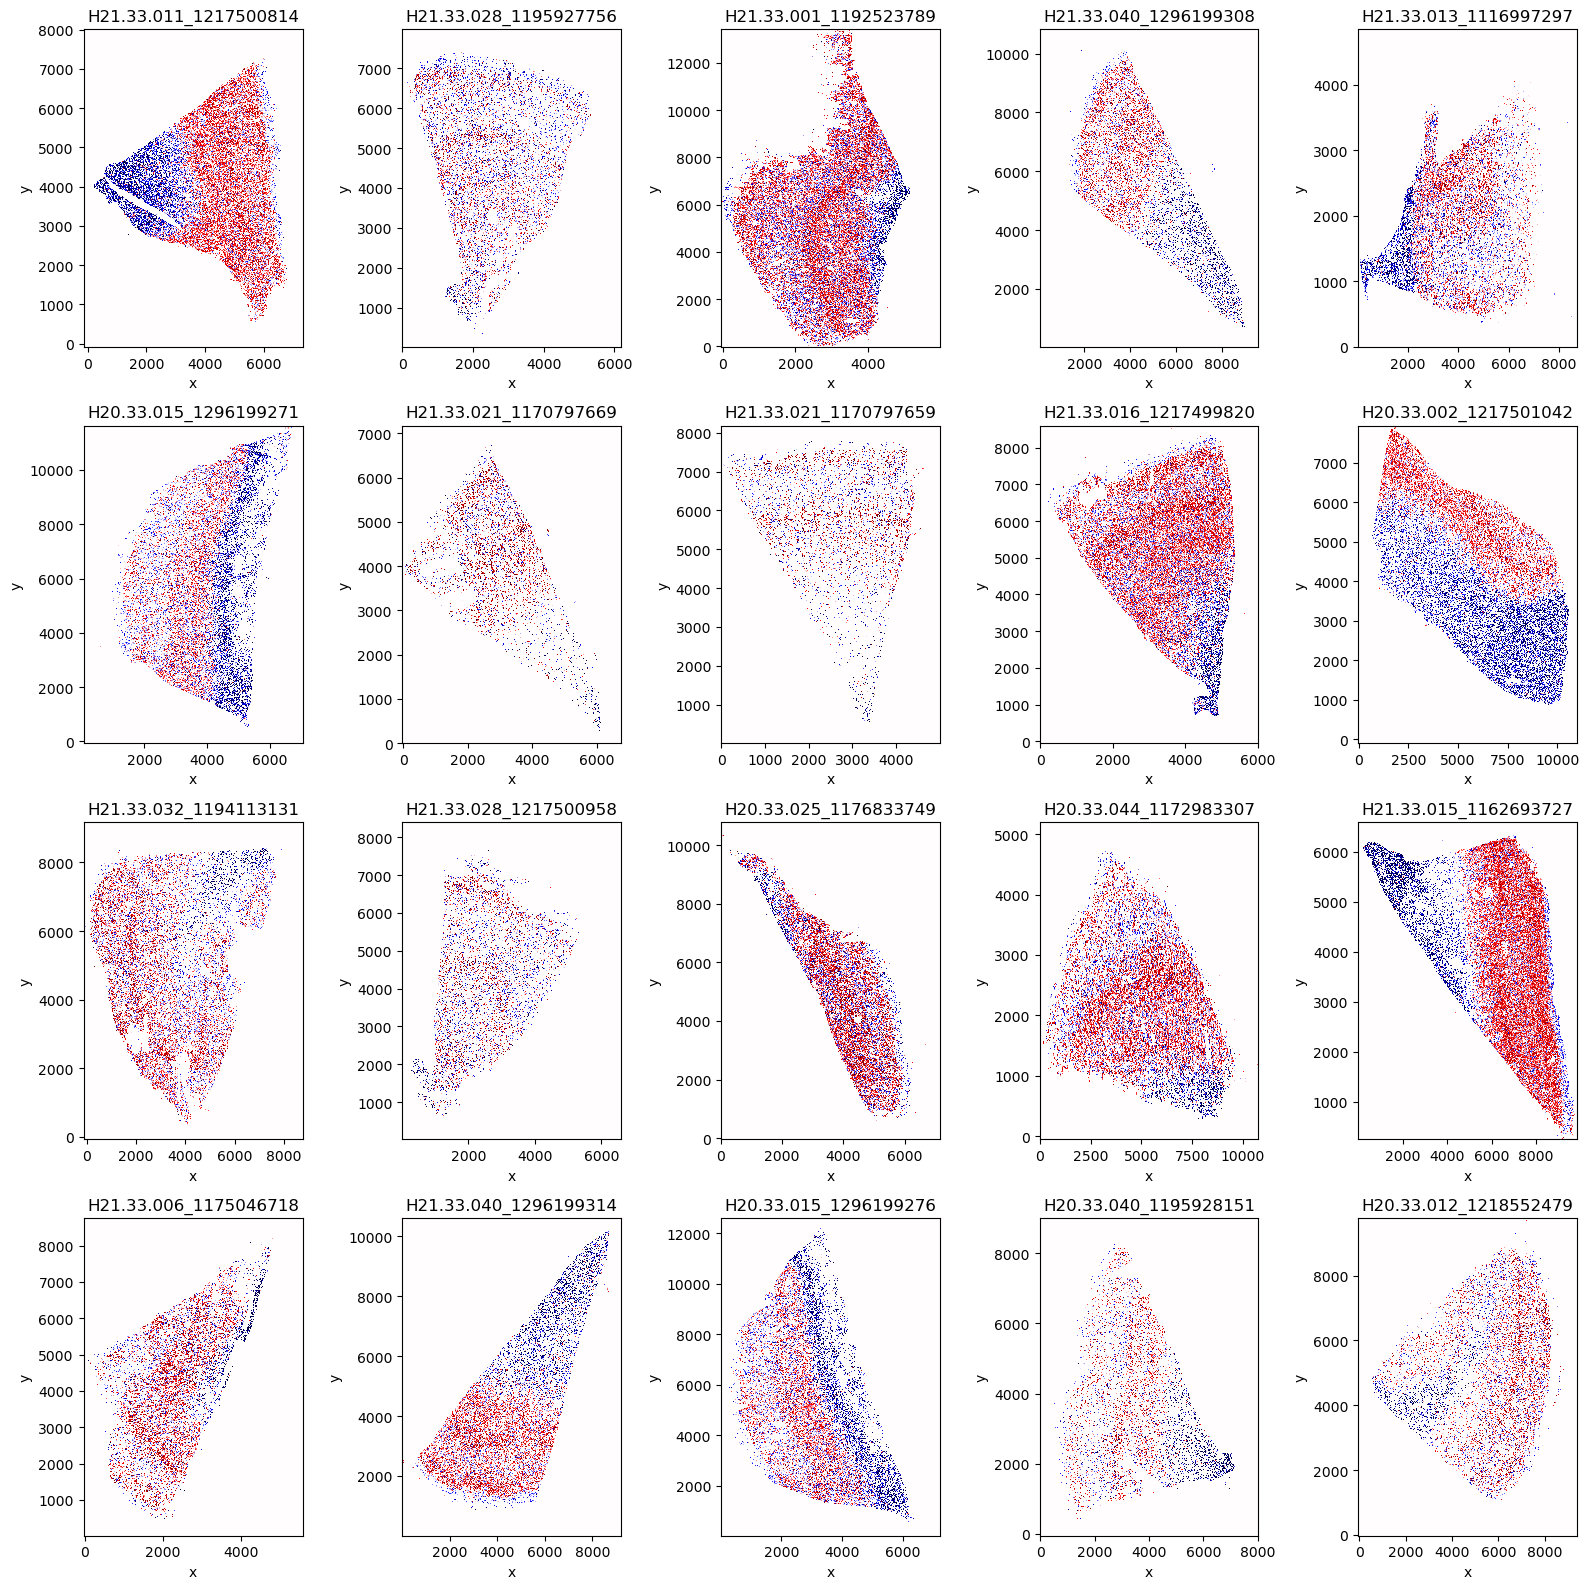

In [4]:
# visual sanity checks
vima.pp.sanity_checks(outdir, repname)